In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time

In [2]:
# 재현성을 위한 시드 고정
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 배치 정규화가 '있는' 모델
class BatchModel(nn.Module):
    def __init__(self,input_n,hidden_n):
        super().__init__()

        self.layer1=nn.Sequential(
            nn.Linear(input_n,hidden_n),
            nn.BatchNorm1d(hidden_n)
        )
        self.relu1=nn.ReLU()
        self.layer2=nn.Sequential(
            nn.Linear(hidden_n,hidden_n),
            nn.BatchNorm1d(hidden_n)
        )
        self.relu2=nn.ReLU()

        self.head=nn.Linear(hidden_n,1)

    def forward(self, x):
      outs=[]
      out=x
      out=self.layer1(out)
      outs.append(out.detach().numpy().flatten())

      out=self.relu1(out)
      outs.append(out.detach().numpy().flatten())

      out=self.layer2(out)
      outs.append(out.detach().numpy().flatten())

      out=self.relu2(out)
      outs.append(out.detach().numpy().flatten())

      out=self.head(out)
      outs.append(out.detach().numpy().flatten())

      return out,outs

# 2. 배치 정규화가 '없는' 모델
class Model(nn.Module):
    def __init__(self,input_n,hidden_n):
        super().__init__()

        self.layer1=nn.Linear(input_n,hidden_n)
        self.relu1=nn.ReLU()
        self.layer2=nn.Linear(hidden_n,hidden_n)
        self.relu2=nn.ReLU()
        self.head=nn.Linear(hidden_n,1)

    def forward(self, x):
      outs=[]
      out=x
      out=self.layer1(out)
      outs.append(out.detach().numpy().flatten())

      out=self.relu1(out)
      outs.append(out.detach().numpy().flatten())

      out=self.layer2(out)
      outs.append(out.detach().numpy().flatten())

      out=self.relu2(out)
      outs.append(out.detach().numpy().flatten())

      out=self.head(out)
      outs.append(out.detach().numpy().flatten())

      return out,outs

    # def __init__(self):
    #     super().__init__()
    #     self.fc_layers = nn.ModuleList([nn.Linear(100, 100) for _ in range(5)])
    #     self.bn_layers = nn.ModuleList([nn.BatchNorm1d(100) for _ in range(5)])
    #     self.relu = nn.ReLU()

    #     # 가중치 초기화 (동일한 조건)
    #     for layer in self.fc_layers:
    #         nn.init.normal_(layer.weight, mean=0, std=0.5)

    # def forward(self, x):
    #     before_activations = []
    #     after_activations=[]
    #     out = x
    #     for fc, bn in zip(self.fc_layers, self.bn_layers):
    #         out = fc(out)
    #         out = bn(out) # 선형 연산 후 BN 적용!
    #         # 활성화 함수(ReLU) 통과 '직전'의 출력 분포를 저장
    #         before_activations.append(out.detach().numpy().flatten())
    #         out = self.relu(out)
    #         after_activations.append(out.detach().numpy().flatten())
    #     return out,before_activations,after_activations



In [10]:

model=Model(1,50)
batch_model=BatchModel(1,50)

batch_size=50
epoch=50
lr=0.01

list(model.named_children())[0]

('layer1', Linear(in_features=1, out_features=50, bias=True))

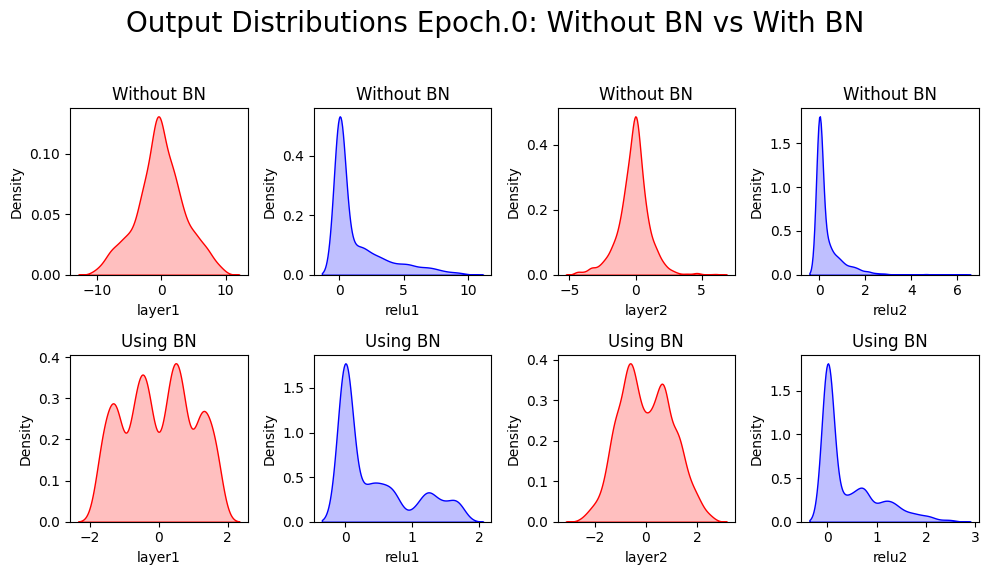

------------------------------


/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)


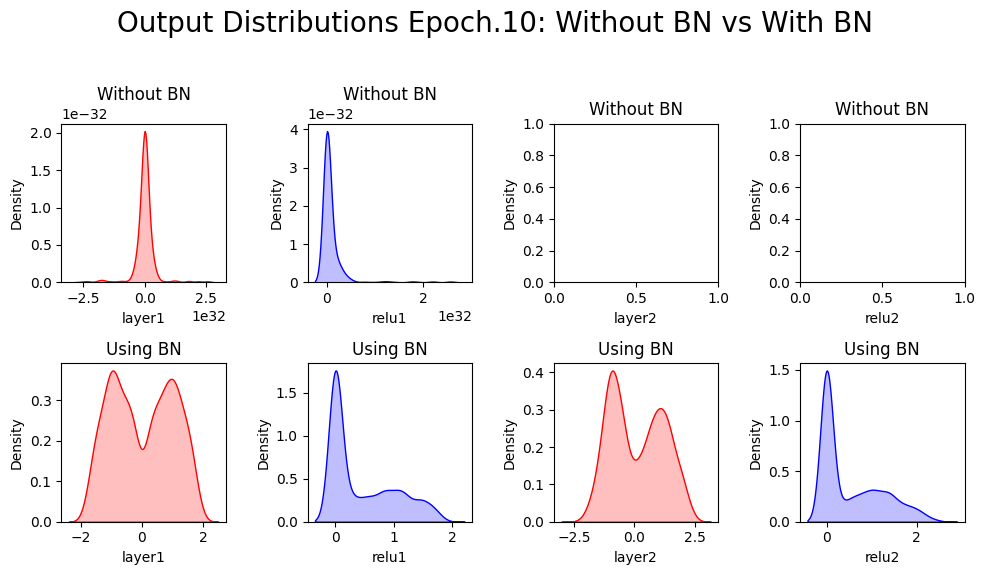

------------------------------


/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)


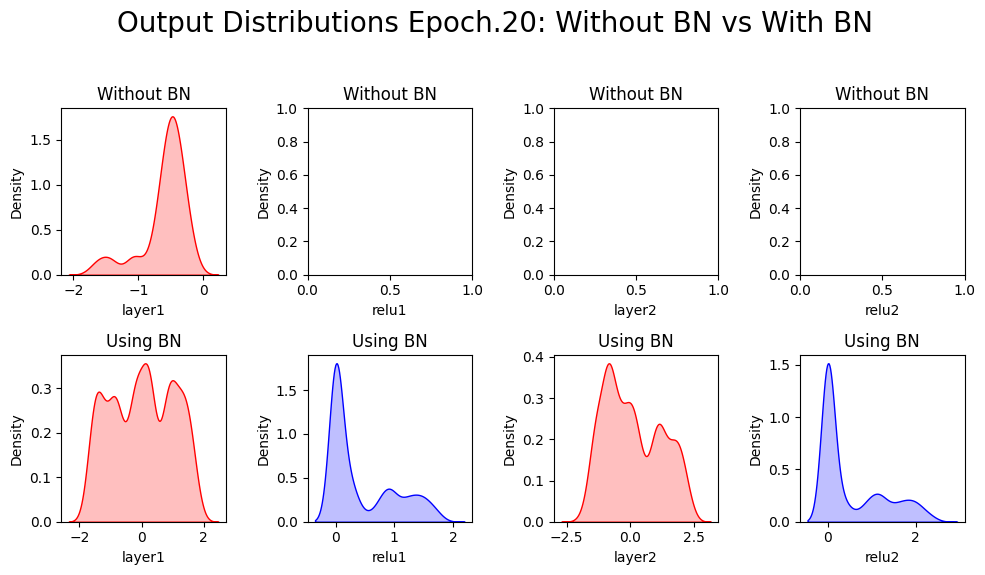

------------------------------


/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)


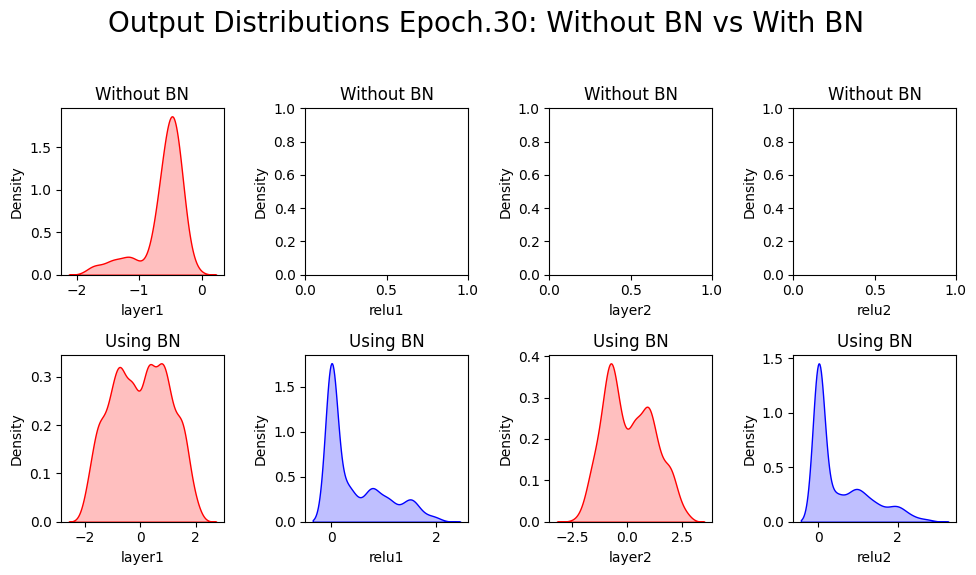

------------------------------


/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
/tmp/ipykernel_615/2868081319.py:36: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)


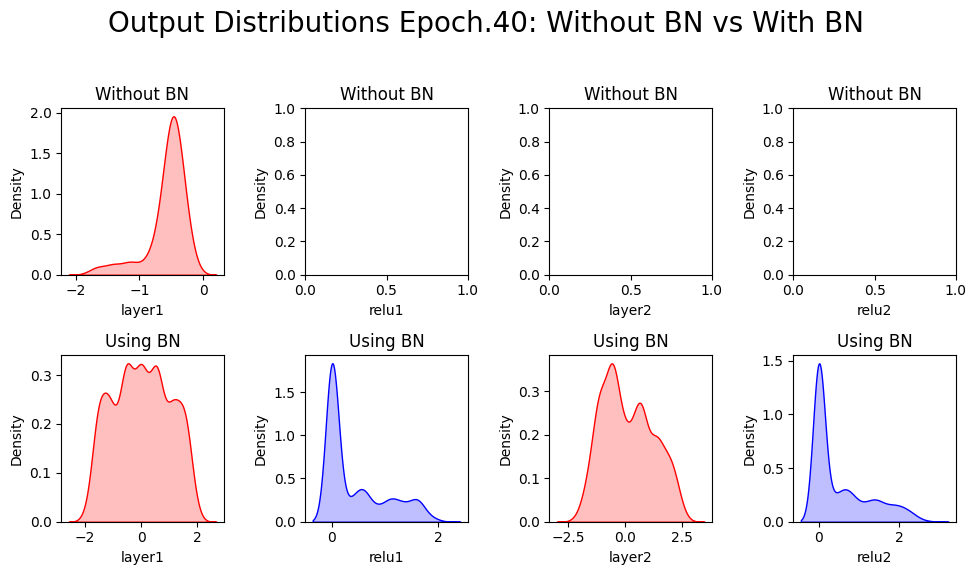

------------------------------
7.125202655792236


In [11]:

model1_layers=[c[0] for c in model.named_children()]
model2_layers=[c[0] for c in batch_model.named_children()]

x = torch.arange(-10.,10.,0.05)
y = 3*x+1

start=time.time()

losses1=[]
losses2=[]

for i in range(epoch):
  indices = torch.randint(0, len(x), (batch_size,1))
  batch_x = x[indices]
  batch_y = y[indices]


  Y1,outs1=model(batch_x)
  Y2,outs2=batch_model(batch_x)

  loss1=((Y1-batch_y)**2).mean()
  loss2=((Y2-batch_y)**2).mean()

  loss1.backward()
  loss2.backward()

  losses1.append(loss1.item())
  losses2.append(loss2.item())

  if i%10==0:
    # 4. 시각화 (그래프 그리기)
    fig, axes = plt.subplots(2, 4, figsize=(10, 6))
    fig.suptitle(f"Output Distributions Epoch.{i}: Without BN vs With BN", fontsize=20)

    for i in range(4):
      sns.kdeplot(outs1[i], ax=axes[0, i], color='red' if i%2==0 else "blue", fill=True)
      axes[0, i].set_title(f"Without BN")
      axes[0, i].set_xlabel(f"{model1_layers[i]}")
      sns.kdeplot(outs2[i], ax=axes[1, i], color='red' if i%2==0 else "blue", fill=True)
      axes[1, i].set_title(f"Using BN")
      axes[1, i].set_xlabel(f"{model2_layers[i]}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("-"*30)

  with torch.no_grad():

    for p in model.parameters():
      if p.grad is not None:
        p -= lr*p.grad
        p.grad.zero_()

    for p in batch_model.parameters():
      if p.grad is not None:
        p -= lr*p.grad
        p.grad.zero_()



print(time.time()-start)

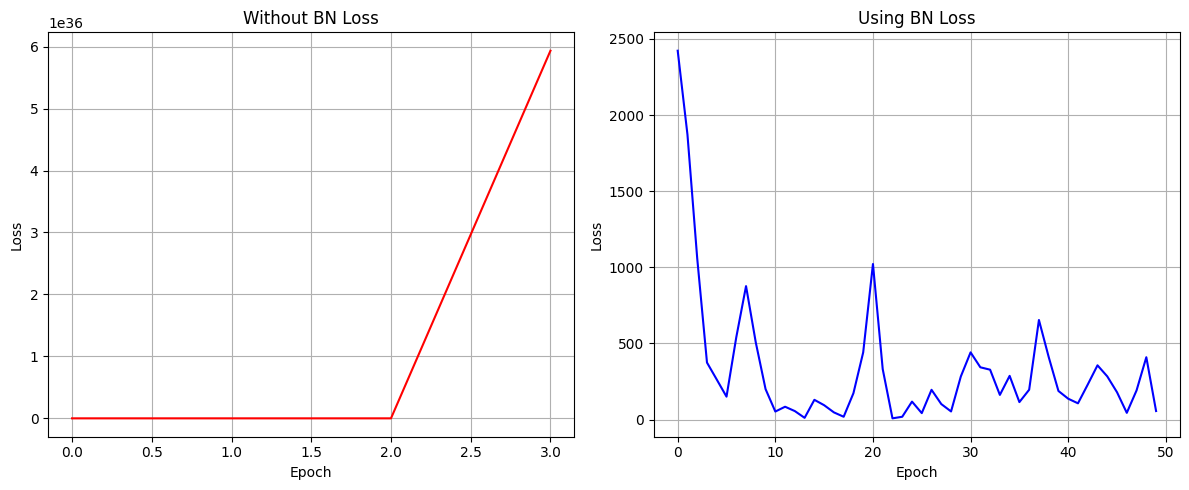

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1번 모델 (Without BN) 그래프
axes[0].plot(losses1, color='red')
axes[0].set_title('Without BN Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# 2번 모델 (Using BN) 그래프
axes[1].plot(losses2, color='blue')
axes[1].set_title('Using BN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

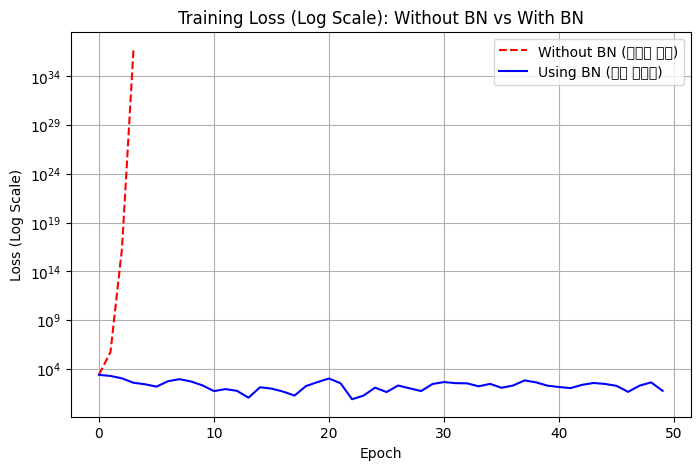

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(losses1, label='Without BN (정규화 없음)', color='red', linestyle='--')
plt.plot(losses2, label='Using BN (배치 정규화)', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Training Loss (Log Scale): Without BN vs With BN')
plt.yscale('log')  # Y축을 로그 스케일로 지정!
plt.legend()
plt.grid(True)
plt.show()